In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("plantpathology/plant-pathology-2021-fgvc8__train.csv")
df["labels"].value_counts()

scab                               4826
healthy                            4624
frog_eye_leaf_spot                 3181
rust                               1860
complex                            1602
powdery_mildew                     1184
scab frog_eye_leaf_spot             686
scab frog_eye_leaf_spot complex     200
frog_eye_leaf_spot complex          165
rust frog_eye_leaf_spot             120
rust complex                         97
powdery_mildew complex               87
Name: labels, dtype: int64

In [4]:
# Only keep 5 labels to simplify the classification problem. Let's use the 5 most common labels without any dual labels
labels_to_keep = ["healthy", "scab", "rust", "frog_eye_leaf_spot", "powdery_mildew"]
df = df[df["labels"].isin(labels_to_keep)]

In [5]:
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df["labels"], random_state=42)
df_train, df_val = train_test_split(df_train, test_size=0.2, stratify=df_train["labels"], random_state=42)
df_train_id, df_train_ood = train_test_split(df_train, test_size=0.15, stratify=df_train["labels"], random_state=42)

In [6]:
df_train_id["labels"].value_counts(), df_train_ood["labels"].value_counts(), df_val["labels"].value_counts(), df_test["labels"].value_counts()

(scab                  2626
 healthy               2515
 frog_eye_leaf_spot    1731
 rust                  1011
 powdery_mildew         644
 Name: labels, dtype: int64,
 scab                  463
 healthy               444
 frog_eye_leaf_spot    305
 rust                  179
 powdery_mildew        114
 Name: labels, dtype: int64,
 scab                  772
 healthy               740
 frog_eye_leaf_spot    509
 rust                  298
 powdery_mildew        189
 Name: labels, dtype: int64,
 scab                  965
 healthy               925
 frog_eye_leaf_spot    636
 rust                  372
 powdery_mildew        237
 Name: labels, dtype: int64)

In [7]:
df_train_id.reset_index(drop=True, inplace=True)
df_train_ood.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

In [8]:
len(df_train_id), len(df_train_ood), len(df_val), len(df_test)

(8527, 1505, 2508, 3135)

In [9]:
df_train_id["stage"] = "train"
df_train_ood["stage"] = "train_wild_in_distribution"
df_val["stage"] = "val"
df_test["stage"] = "test"

In [10]:
df_dataset = pd.concat([df_train_id, df_train_ood, df_val, df_test], axis=0)
df_dataset.reset_index(drop=True, inplace=True)
df_dataset.rename(columns={"labels": "label", "image": "image_path"}, inplace=True)

In [11]:
df_dataset["id"] = "plant_pathology_" + df_dataset.index.astype(str)
df_dataset = df_dataset[["id", "image_path", "label", "stage"]]
df_dataset.head()

,id,image_path,label,stage
0,plant_pathology_0,d3c96892b78e4674.jpg,rust,train
1,plant_pathology_1,c53c6034c0fb87d7.jpg,frog_eye_leaf_spot,train
2,plant_pathology_2,a087da68597743f4.jpg,scab,train
3,plant_pathology_3,a88f9e58d209ad75.jpg,healthy,train
4,plant_pathology_4,a26add35f4737005.jpg,healthy,train


In [12]:
df_dataset.to_csv("dataset.csv", index=False)

In [13]:
df_dataset["image_path"].nunique(), df_dataset["id"].nunique()

(15675, 15675)

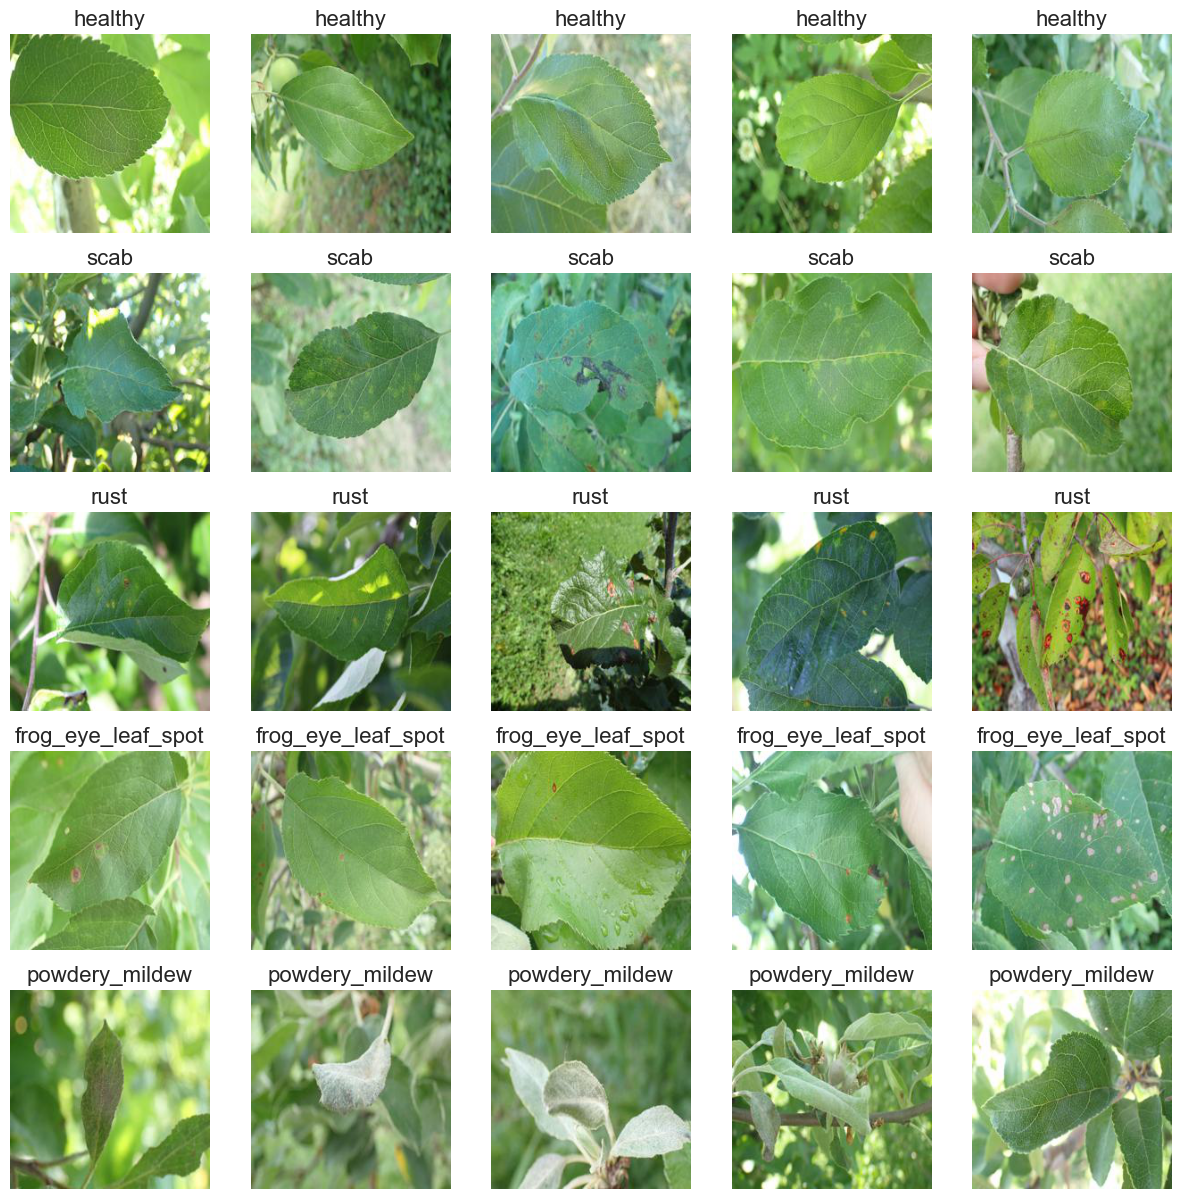

In [12]:
# Let's randomly sample 3 images per label from train to visualize the dataset
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from random import sample
sns.set_style("whitegrid")
plt.figure(figsize=(15, 15))
df_train = df_dataset[df_dataset["stage"] == "train"]
for i, label in enumerate(labels_to_keep):
    df_label = df_train[df_train["label"] == label]
    sampled_images = sample(list(df_label["image_path"]), 5)
    for j, image_path in enumerate(sampled_images):
        plt.subplot(len(labels_to_keep), 5, i * 5 + j + 1)
        img = cv2.imread(os.path.join("./images_resized/", image_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis("off")
        plt.title(label, fontsize=16)

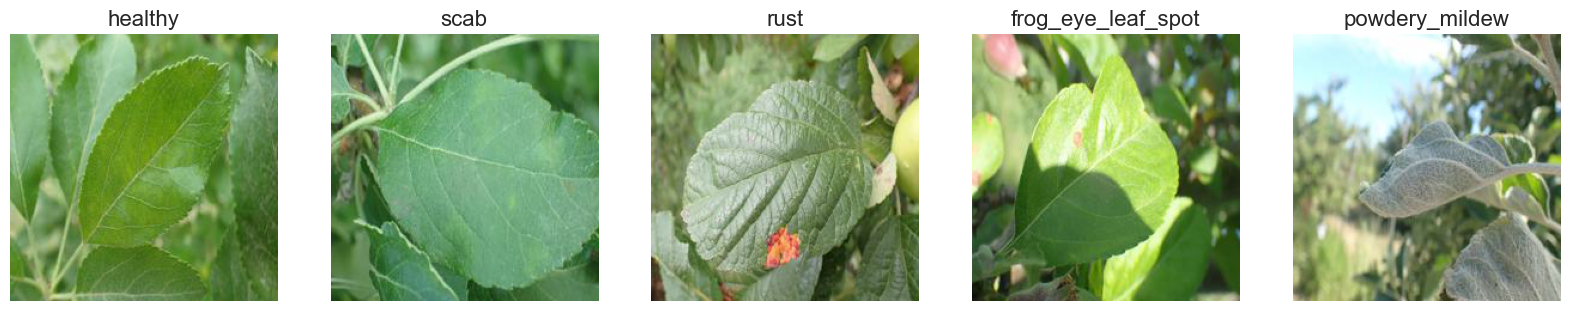

In [13]:
# now do the same as above but only do one per class and make it one row of images
plt.figure(figsize=(20, 5))
for i, label in enumerate(labels_to_keep):
    df_label = df_train[df_train["label"] == label]
    sampled_image = sample(list(df_label["image_path"]), 1)[0]
    plt.subplot(1, len(labels_to_keep), i + 1)
    img = cv2.imread(os.path.join("./images_resized/", sampled_image))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
    plt.title(label, fontsize=16)